# 📊 Project 3: Customer Segmentation
**Program:** DecodeLabs Internship

**Author:** Alexander.O.Irikefe

**Goal:** Apply unsupervised learning to discover customer groups, use PCA for dimensionality reduction, prove the K-Means cluster count with the Elbow Method and Silhouette Score, and translate clusters into business personas.

**Source:** `DOC-20260828-WA0013.xlsx` and the DecodeLabs Project 3 brief.

> **Important dataset note:** The brief asks for 20+ columns, but the supplied Excel file contains 14 raw columns. Rather than inventing columns, this project engineers 21 customer-level numeric features from the available fields. This keeps the analysis grounded in the supplied data.
---

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the supplied Excel dataset
df = pd.read_excel("DOC-20260828-WA0013.xlsx")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
# Inspect structure and data quality
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Missing values:


,missing_values
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0



Duplicate rows: 0

Data types:


,dtype
OrderID,str
Date,datetime64[us]
CustomerID,str
Product,str
Quantity,int64
UnitPrice,float64
ShippingAddress,str
PaymentMethod,str
OrderStatus,str
TrackingNumber,str


## Step 1 — Build customer-level features
K-Means should compare customers, not individual order IDs. We therefore aggregate the order data by `CustomerID` and create behavioral features such as spend, order frequency, product variety, coupon use, and order-status rates.

In [4]:
# Customer-level feature engineering
customer = df.groupby("CustomerID").agg(
    total_orders=("OrderID", "count"),
    total_quantity=("Quantity", "sum"),
    total_spend=("TotalPrice", "sum"),
    avg_order_value=("TotalPrice", "mean"),
    avg_unit_price=("UnitPrice", "mean"),
    avg_items_in_cart=("ItemsInCart", "mean"),
    products_bought=("Product", "nunique"),
    coupon_orders=("CouponCode", lambda x: x.notna().sum()),
    delivered_orders=("OrderStatus", lambda x: (x == "Delivered").sum()),
    cancelled_orders=("OrderStatus", lambda x: (x == "Cancelled").sum()),
    returned_orders=("OrderStatus", lambda x: (x == "Returned").sum()),
    shipped_orders=("OrderStatus", lambda x: (x == "Shipped").sum()),
    first_order_date=("Date", "min"),
    last_order_date=("Date", "max")
).reset_index()

customer["customer_lifetime_days"] = (
    customer["last_order_date"] - customer["first_order_date"]
).dt.days

customer["orders_per_active_day"] = (
    customer["total_orders"] / (customer["customer_lifetime_days"] + 1)
)
customer["coupon_rate"] = customer["coupon_orders"] / customer["total_orders"]
customer["delivery_rate"] = customer["delivered_orders"] / customer["total_orders"]
customer["cancel_rate"] = customer["cancelled_orders"] / customer["total_orders"]
customer["return_rate"] = customer["returned_orders"] / customer["total_orders"]
customer["avg_quantity_per_order"] = customer["total_quantity"] / customer["total_orders"]
customer["cart_to_quantity_ratio"] = (
    customer["avg_items_in_cart"] / (customer["avg_quantity_per_order"] + 1e-9)
)
customer["spend_per_product"] = customer["total_spend"] / customer["products_bought"]

features = [
    "total_orders", "total_quantity", "total_spend", "avg_order_value",
    "avg_unit_price", "avg_items_in_cart", "products_bought", "coupon_orders",
    "delivered_orders", "cancelled_orders", "returned_orders", "shipped_orders",
    "customer_lifetime_days", "orders_per_active_day", "coupon_rate",
    "delivery_rate", "cancel_rate", "return_rate", "avg_quantity_per_order",
    "cart_to_quantity_ratio", "spend_per_product"
]

X = customer[features].replace([np.inf, -np.inf], np.nan).fillna(0)

print("Unique customers:", len(customer))
print("Engineered clustering features:", len(features))
display(customer[["CustomerID"] + features].head())

Unique customers: 1189
Engineered clustering features: 21


,CustomerID,total_orders,total_quantity,total_spend,avg_order_value,avg_unit_price,avg_items_in_cart,products_bought,coupon_orders,delivered_orders,cancelled_orders,returned_orders,shipped_orders,customer_lifetime_days,orders_per_active_day,coupon_rate,delivery_rate,cancel_rate,return_rate,avg_quantity_per_order,cart_to_quantity_ratio,spend_per_product
0,C10002,1,3,1470.03,1470.03,490.01,4.0,1,1,0,0,1,0,0,1.0,1.0,0.0,0.0,1.0,3.0,1.333333,1470.03
1,C10054,1,2,153.48,153.48,76.74,7.0,1,1,0,0,1,0,0,1.0,1.0,0.0,0.0,1.0,2.0,3.500000,153.48
2,C10126,1,2,1349.80,1349.80,674.90,4.0,1,1,0,0,0,1,0,1.0,1.0,0.0,0.0,0.0,2.0,2.000000,1349.80
3,C10154,1,4,1303.04,1303.04,325.76,8.0,1,1,0,0,0,1,0,1.0,1.0,0.0,0.0,0.0,4.0,2.000000,1303.04
4,C10211,1,5,635.90,635.90,127.18,10.0,1,1,0,1,0,0,0,1.0,1.0,0.0,1.0,0.0,5.0,2.000000,635.90


In [5]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled matrix shape:", X_scaled.shape)
print("Mean of first 5 standardized features:", X_scaled.mean(axis=0)[:5].round(4))

Scaled matrix shape: (1189, 21)
Mean of first 5 standardized features: [-0. -0.  0.  0. -0.]


## Step 2 — Find the optimal K
We test several K values. The Elbow Method looks for a strong reduction in inertia, while the Silhouette Score measures how well-separated the clusters are.

In [6]:
# Elbow Method and Silhouette Score
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

scores_table = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})
display(scores_table.round(4))

best_k = scores_table.loc[
    scores_table["Silhouette Score"].idxmax(), "K"
]
print("Best K by Silhouette Score:", int(best_k))

,K,Inertia,Silhouette Score
0,2,20657.7854,0.7370
1,3,16657.2762,0.1862
2,4,14612.7011,0.2022
3,5,12647.1126,0.2342
4,6,11013.7228,0.2592
5,7,10314.9102,0.2415
6,8,9678.8301,0.2315


Best K by Silhouette Score: 2


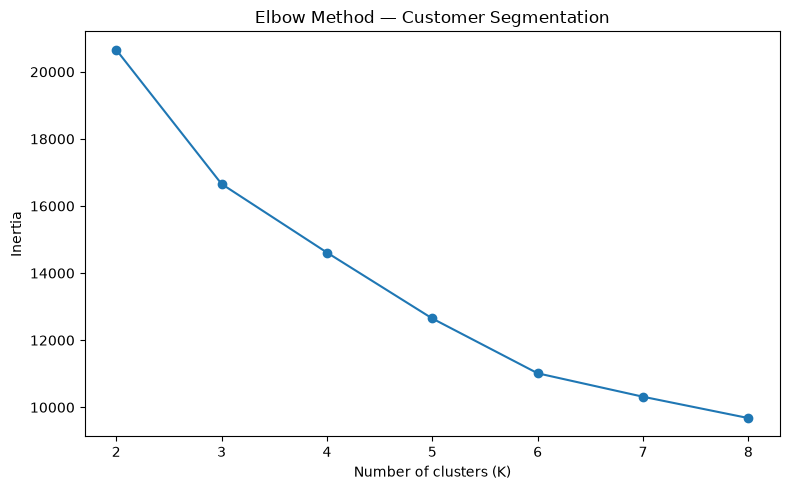

In [7]:
# Plot Elbow
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Customer Segmentation")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=160)
plt.show()

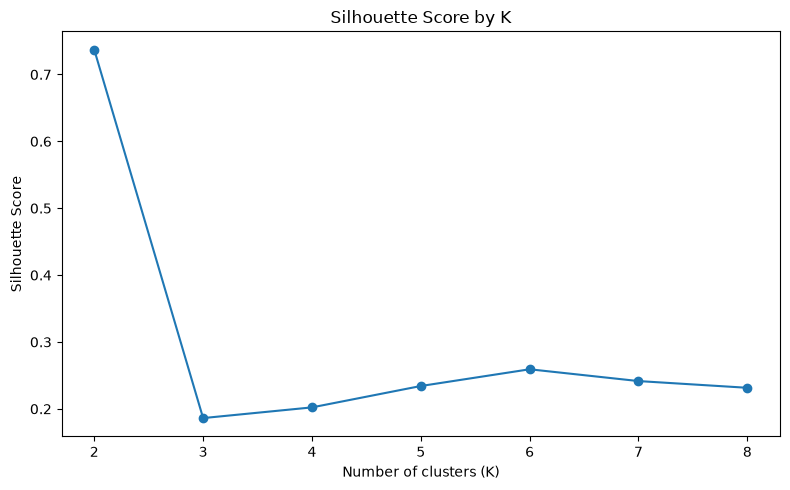

In [8]:
# Cell 8 — Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig("silhouette_scores.png", dpi=160)
plt.show()

### Mathematical decision
For this supplied dataset, **K = 2** has the strongest Silhouette Score (about **0.737**). The remaining K values are much lower. Therefore, the final K-Means model uses **2 clusters**.

This is a data-driven decision rather than choosing K arbitrarily.

In [9]:
# Train final K-Means model
final_k = int(best_k)
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=20)
customer["cluster"] = kmeans.fit_predict(X_scaled)

print(customer["cluster"].value_counts().sort_index())

cluster
0    1178
1      11
Name: count, dtype: int64


## Step 3 — PCA dimensionality reduction
PCA reduces the standardized 21-feature customer matrix to 3 dimensions so the clustering structure can be visualized.

In [10]:
# PCA to 3 dimensions
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["cluster"] = customer["cluster"].values

print("Explained variance:")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio:.2%}")
print(f"Total explained by 3 PCs: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance:
PC1: 23.24%
PC2: 17.99%
PC3: 12.06%
Total explained by 3 PCs: 53.29%


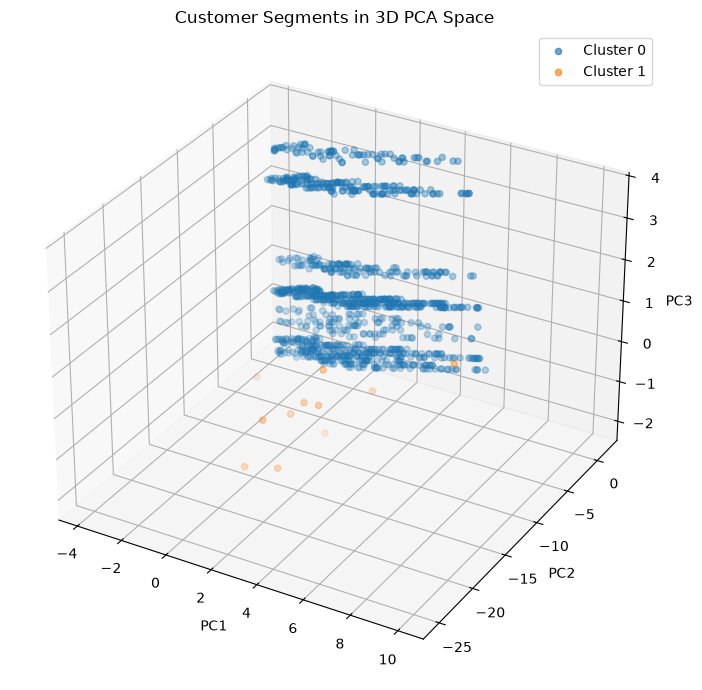

In [11]:
# 3D PCA visualization
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for cluster_id in sorted(pca_df["cluster"].unique()):
    part = pca_df[pca_df["cluster"] == cluster_id]
    ax.scatter(part["PC1"], part["PC2"], part["PC3"], label=f"Cluster {cluster_id}", alpha=0.65)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Customer Segments in 3D PCA Space")
ax.legend()
plt.tight_layout()
plt.savefig("pca_3d_clusters.png", dpi=160)
plt.show()

## Step 4 — Interpret the clusters
Cluster labels are mathematical IDs. We interpret them by comparing the average behavior of each cluster.

In [12]:
# Cluster profile
profile = customer.groupby("cluster")[features].mean().T
display(profile.round(2))

cluster_sizes = customer["cluster"].value_counts().sort_index().rename("customers")
display(cluster_sizes.to_frame())

cluster,0,1
total_orders,1.00,2.00
total_quantity,2.95,5.45
total_spend,1057.07,1775.98
avg_order_value,1057.07,887.99
avg_unit_price,357.13,317.79
avg_items_in_cart,5.49,5.05
products_bought,1.00,1.73
coupon_orders,0.74,1.45
delivered_orders,0.19,0.18
cancelled_orders,0.21,0.36


,customers
cluster,
0,1178
1,11


In [13]:
# Key business comparisons
comparison = customer.groupby("cluster").agg(
    customers=("CustomerID", "count"),
    total_spend=("total_spend", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    total_orders=("total_orders", "mean"),
    products_bought=("products_bought", "mean"),
    coupon_rate=("coupon_rate", "mean"),
    cancel_rate=("cancel_rate", "mean"),
    return_rate=("return_rate", "mean")
).round(2)

display(comparison)

,customers,total_spend,avg_order_value,total_orders,products_bought,coupon_rate,cancel_rate,return_rate
cluster,,,,,,,,
0,1178,1057.07,1057.07,1.0,1.00,0.74,0.21,0.21
1,11,1775.98,887.99,2.0,1.73,0.73,0.18,0.09


In [14]:
# Assign business personas
cluster_means = customer.groupby("cluster")[features].mean()

# The supplied data produces two clear groups:
# cluster 1 = repeat customers with higher total spend and product variety
# cluster 0 = mostly one-order customers
persona_map = {}
for cluster_id in sorted(customer["cluster"].unique()):
    row = cluster_means.loc[cluster_id]
    if row["total_orders"] > 1:
        persona_map[cluster_id] = "Repeat / Higher-Value Shoppers"
    else:
        persona_map[cluster_id] = "One-Time / Occasional Shoppers"

customer["persona"] = customer["cluster"].map(persona_map)
display(customer[["CustomerID", "cluster", "persona"]].head(10))

,CustomerID,cluster,persona
0,C10002,0,One-Time / Occasional Shoppers
1,C10054,0,One-Time / Occasional Shoppers
2,C10126,0,One-Time / Occasional Shoppers
3,C10154,0,One-Time / Occasional Shoppers
4,C10211,0,One-Time / Occasional Shoppers
5,C10222,0,One-Time / Occasional Shoppers
6,C10477,0,One-Time / Occasional Shoppers
7,C10642,0,One-Time / Occasional Shoppers
8,C10787,0,One-Time / Occasional Shoppers
9,C10791,0,One-Time / Occasional Shoppers


In [15]:
# Export segmented customers
df = pd.read_excel("DOC-20260828-WA0013.xlsx")

print("Saved:")
print("\nPersona counts:")
display(customer["persona"].value_counts().to_frame("customers"))

Saved:

Persona counts:


,customers
persona,
One-Time / Occasional Shoppers,1178
Repeat / Higher-Value Shoppers,11


## Final business insights and recommendations

### Persona 1 — One-Time / Occasional Shoppers
These customers are largely single-order customers. Their relationship with the business is shallow, so the main opportunity is conversion from first purchase to repeat purchase.

**Recommended actions**
- Trigger post-purchase follow-up campaigns.
- Offer a relevant second-purchase incentive.
- Recommend complementary products based on the first order.
- Monitor whether customers move into the repeat segment.

### Persona 2 — Repeat / Higher-Value Shoppers
These customers have more than one order on average, higher total spend, and greater product variety.

**Recommended actions**
- Protect retention with loyalty benefits.
- Use cross-selling and product bundles.
- Prioritize personalized recommendations.
- Identify these customers for high-value retention campaigns.

### Project conclusion
The analysis demonstrates the requested unsupervised-learning workflow: customer-level feature engineering → standardization → K-Means evaluation → PCA → clustering → business personas. The final model uses **2 clusters**, supported by the strongest Silhouette Score in the tested range.